## Setup

In [63]:
# change into the src directory
import git
import os

repo = git.Repo('.', search_parent_directories=True)
os.chdir(repo.working_tree_dir)

In [64]:
from tapas_gmm.policy.models.tpgmm import ModelType, TPGMM, ReconstructionStrategy, FittingStage, InitStrategy, _xdx_to_tangent, TPGMMConfig, AutoTPGMMConfig, AutoTPGMM, FrameSelectionConfig, DemoSegmentationConfig, CascadeConfig
# import lovely_tensors as lt
# lt.monkey_patch()
from lovely_numpy import lo
import matplotlib.pyplot as plt

import pathlib
#from pbdlib.utils.jupyter_utils import *
import numpy as np

from conf._machine import data_naming_config as machine_data_naming_config
from tapas_gmm.dataset.demos import Demos, PartialFrameViewDemos
import tapas_gmm.policy.models.tpgmm
from tapas_gmm.utils.misc import load_scene_data, DataNamingConfig
from tapas_gmm.utils.logging import setup_logger  # noqa: F401
from tapas_gmm.viz.gmm import plot_log_map_quaternions, plot_hmm_transition_matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

data_root = pathlib.Path(machine_data_naming_config.data_root).resolve()
data_root = data_root.parent / data_root.stem

np.set_printoptions(precision=2)

plt.style.use('default')

from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
#task = 'TurnOnLight'
serie = 'demos'
task = 'PressButton'
path = data_root / task / serie

data_config = DataNamingConfig(
    feedback_type=None,
    task=None,
    data_root=None,
    path=path,
)

scene_data = load_scene_data(data_config)
print(scene_data.sample_data_point_with_ground_truth(cam="wrist"))


SingleCamSceneObservation(
    action=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    depth=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
    ee_pose=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    extr=Tensor(shape=torch.Size([4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
    feedback=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
    intr=Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
    mask=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.uint8, is_shared=False),
    object_poses=TensorDict(
        fields={
            base__button: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__drawer: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__slide: Tensor(shape=torch.Size([7]), 

In [66]:
gt_pose_config = {
    #'indeces': [1,2,3,4],
}

gt_kp_config = {
    'encoder_name': 'demos_keypoints_gt_encoder-world',
    'cam': 'front',
}

kp_config = {
    'encoder_name': 'demos_vit_keypoints_encoder',
    'encoding_name': 'gtcopy',
}


In [67]:
observations = scene_data.get_demos(**gt_pose_config)
print(observations[0].keys())
print(observations[0])
n_obs = len(observations)

demo_meta_data = {
    'path': path
}

data_kwargs = dict(
    meta_data=demo_meta_data,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True
)

demos = Demos(observations, **data_kwargs)
print(demos)

_LazyStackedTensorDictKeysView(['action', 'cameras', 'ee_pose', 'feedback', 'gripper_state', 'joint_pos', 'joint_vel', 'object_poses', 'object_states'],
    include_nested=False,
    leaves_only=False)
SceneObservation(
    action=Tensor(shape=torch.Size([88, 7]), device=cpu, dtype=torch.float32, is_shared=False),
    cameras=LazyStackedTensorDict(
        fields={
            _order: CameraOrder(
                order=('wrist',),
                batch_size=torch.Size([88]),
                device=None,
                is_shared=False),
            wrist: SingleCamObservation(
                depth=Tensor(shape=torch.Size([88, 256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
                extr=Tensor(shape=torch.Size([88, 4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                intr=Tensor(shape=torch.Size([88, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                rgb=Tensor(shape=torch.Size([88, 3, 256, 256]), device=cpu, dtype=to

In [68]:
tag="release"

tpgmm_config = TPGMMConfig(
    n_components=10,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,  # Use rotation aswell?
    add_gripper_action=True,
    heal_time_variance=False,
    reg_shrink=1e-2, # 1e-2 is 0.01
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,

    em_steps=50,
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    rel_score_threshold=0.75,
    use_bic=False,  # Does prune segmentation
    drop_redundant_frames=False,
    gt_frames=[
        [0],
        [0],
    ],  # Example ground truth frames for testing
)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    velocity_threshold=0.001,
    components_prop_to_len=True,
    min_end_distance=10,
)

cascade_config = CascadeConfig()

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [69]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2025-08-16 02:04:50.771 | INFO     |  Fitting AutoTPGMM
2025-08-16 02:04:50.771 | INFO     |  Segmenting trajectories


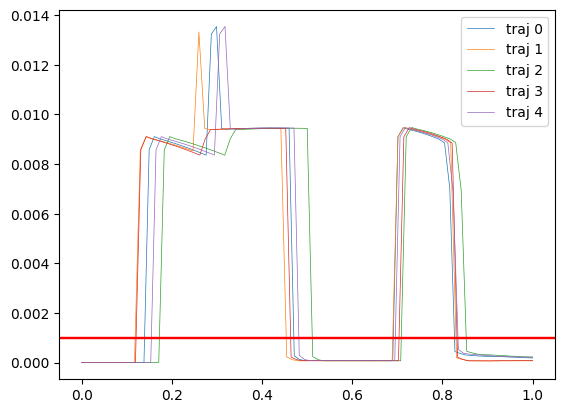

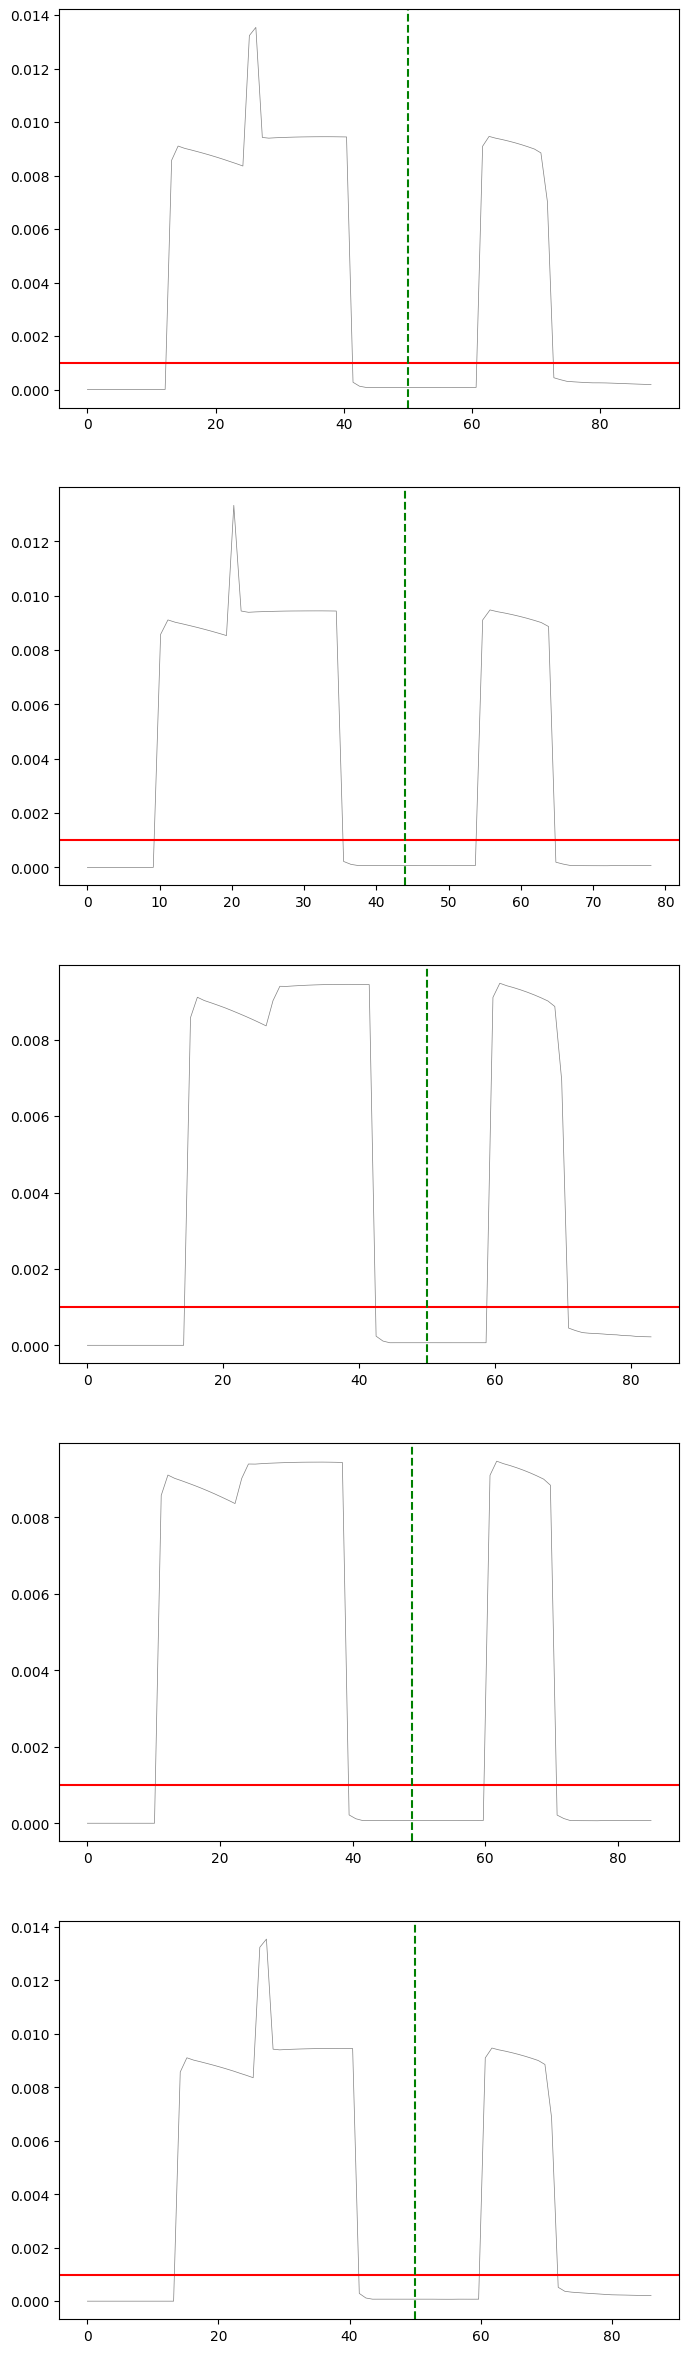

2025-08-16 02:04:50.981 | INFO     |  Creating segement of demos.
2025-08-16 02:04:50.983 | INFO     |  Creating segement of demos.
2025-08-16 02:04:50.985 | INFO     |  ... created 2 segments
2025-08-16 02:04:50.985 | INFO     |    Fitting candidate frame 1/10
2025-08-16 02:04:50.985 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-16 02:04:51.040 | INFO     |    Fitting candidate frame 2/10
2025-08-16 02:04:51.040 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-16 02:04:51.118 | INFO     |    Fitting candidate frame 3/10
2025-08-16 02:04:51.119 | INFO     |    Creating partial frame view of demos.


...

2025-08-16 02:04:52.526 | INFO     |  Creating partial frame view of demos.
2025-08-16 02:04:52.527 | INFO     |  Segmented trajs into 2 segments
2025-08-16 02:04:52.530 | INFO     |  Frame score (abs):
            ee_init  base__button  base__drawer  base__slide  base__switch  \
Segment 0 -0.247858     -0.247858     -0.006376    -0.007743     -0.020997   
Segment 1 -0.246139     -0.245989     -0.003542    -0.001610     -0.029025   

           block_blue  block_pink  block_red       led  lightbulb  
Segment 0   -0.000024   -0.000004   -0.00001 -0.247858  -0.247858  
Segment 1   -0.000009   -0.000001   -0.00001 -0.245989  -0.246033  
2025-08-16 02:04:52.532 | INFO     |  Frame score (rel):
           ee_init  base__button  base__drawer  base__slide  base__switch  \
Segment 0      1.0      1.000000      0.025725     0.031241      0.084716   
Segment 1      1.0      0.999389      0.014390     0.006542      0.117923   

           block_blue  block_pink  block_red       led  lightbulb  
S

Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

((array([[1.94e+013, 1.94e+013, 6.91e+012, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [3.50e+010, 7.29e+010, 1.38e+011, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [1.38e-026, 6.53e-025, 2.56e-023, ..., 4.50e-017, 6.43e-018,
          7.57e-019],
         [4.00e-121, 4.78e-119, 5.20e-117, ..., 4.72e+009, 3.48e+009,
          2.33e+009]]),
  array([[6.80e+012, 6.84e+012, 2.65e+012, 3.95e+011, 2.27e+010, 5.02e+008,
          4.28e+006, 1.40e+004, 1.78e+001, 8.67e-003, 1.62e-006, 5.33e-011,
          1.13e-016, 1.60e-023, 1.56e-031, 1.08e-040, 5.59e-051, 2.25e-062,
          7.41e-075, 2.12e-088, 6.06e-103, 6.02e-117, 5.60e-125, 7.39e-134,
          3.75e-143, 7.10e-153, 5.08e-163, 1.37e-173, 1.41e-184, 5.54e-196,
          8.27e-208, 4.66e-220, 9.92e-233, 7.97e-246, 2.43e-259, 2.80e-273,
          8.73e-288, 1.05e-302, 4.85e-318, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 6.75e+012, 6.73e+012, 2.58e+012, 3.81e+011,
          2.17e+010, 4

In [70]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.INIT,))


2025-08-16 02:04:52.733 | INFO     |  Did not specify time_based, deciding automatically.


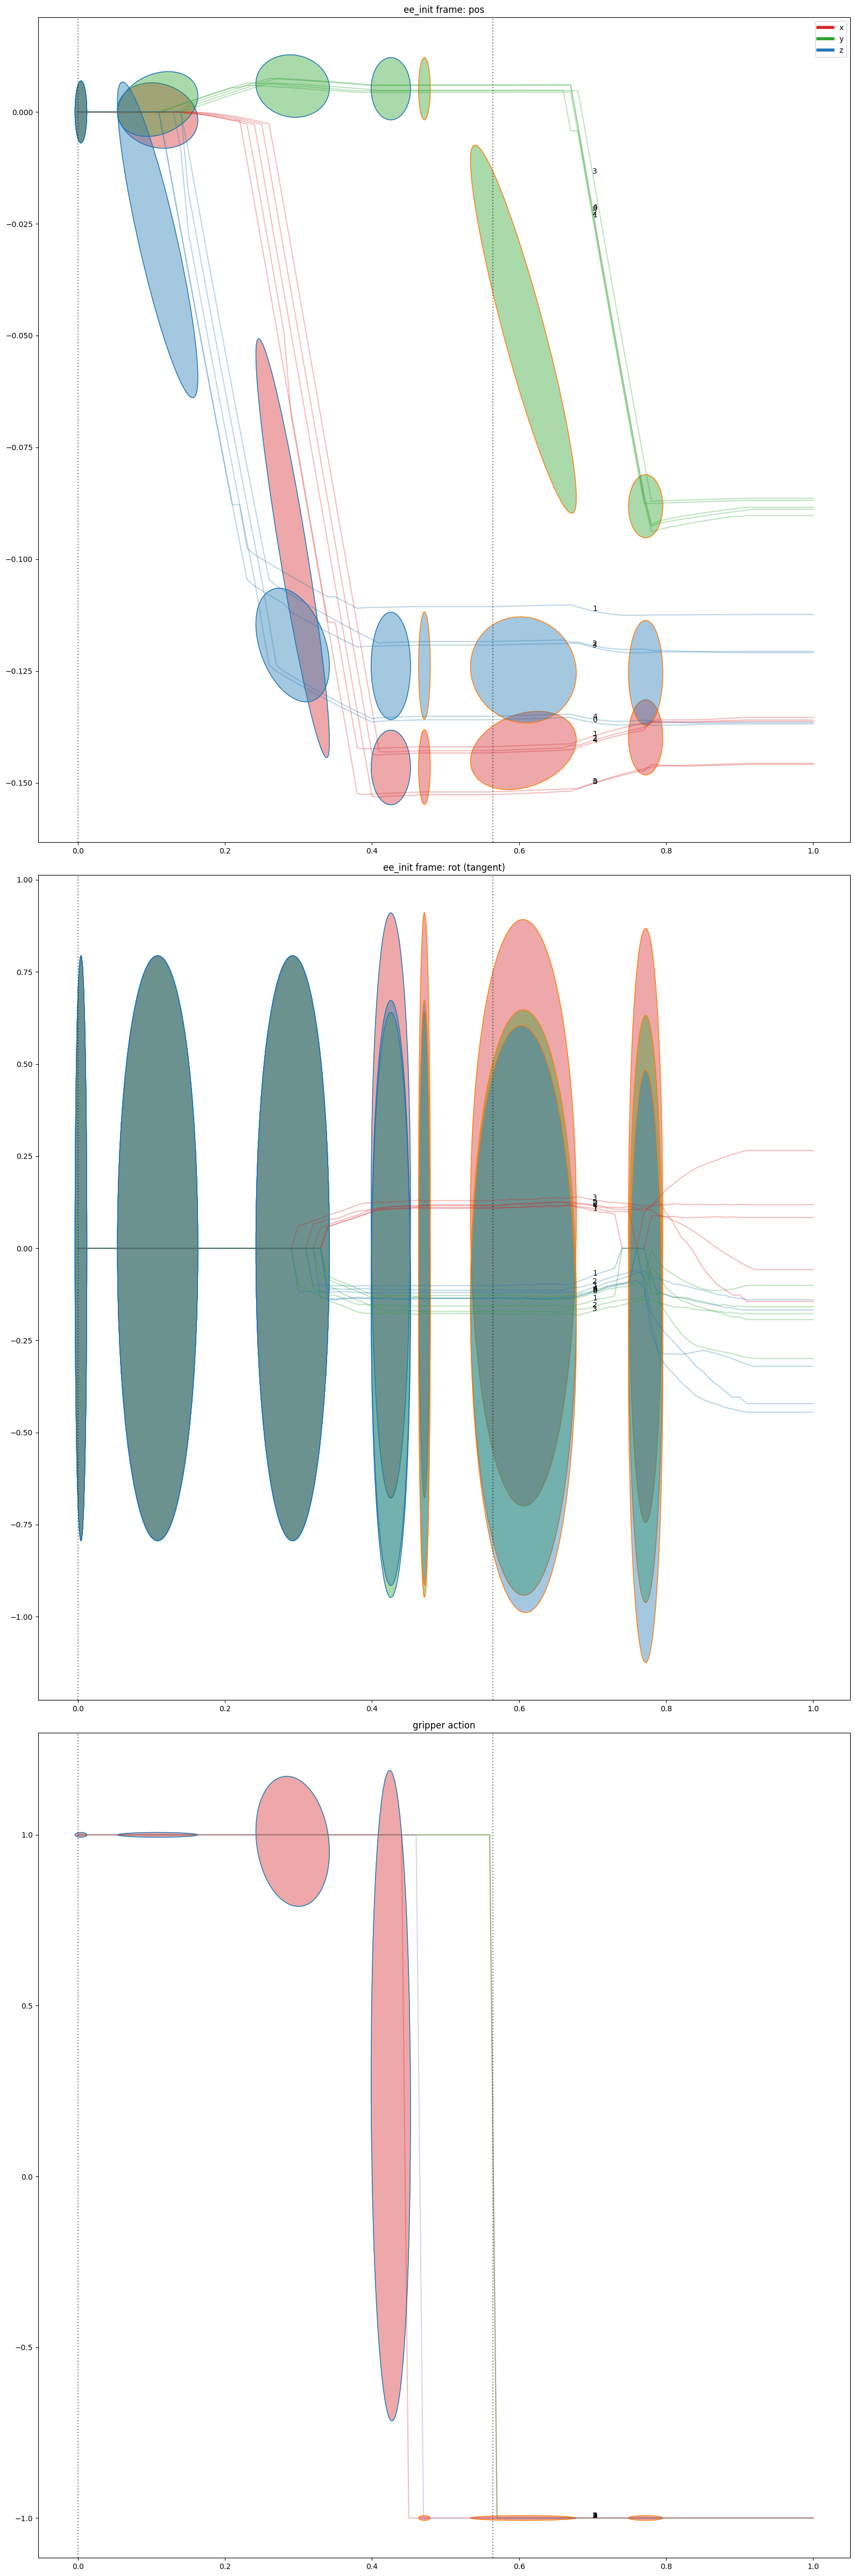

In [71]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [72]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2025-08-16 02:04:53.299 | INFO     |  Fitting AutoTPGMM


Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[1.00e+000, 1.00e+000, 1.00e+000, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 1.04e-018, 1.01e-012, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 4.12e-244, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 1.00e+000, 1.00e+000,
          1.00e+000]]),
  array([[1.00e+000, 1.00e+000, 1.00e+000, 1.00e+000, 9.97e-001, 6.12e-001,
          5.66e-003, 1.33e-007, 3.37e-015, 3.91e-026, 8.84e-041, 5.15e-060,
          5.20e-085, 6.43e-117, 7.09e-157, 5.24e-206, 2.03e-265, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 1.00e+000, 1.00e+000, 1.00e+000, 1.00e+000,
          9.97e-001, 6

2025-08-16 02:04:55.884 | INFO     |  Did not specify time_based, deciding automatically.


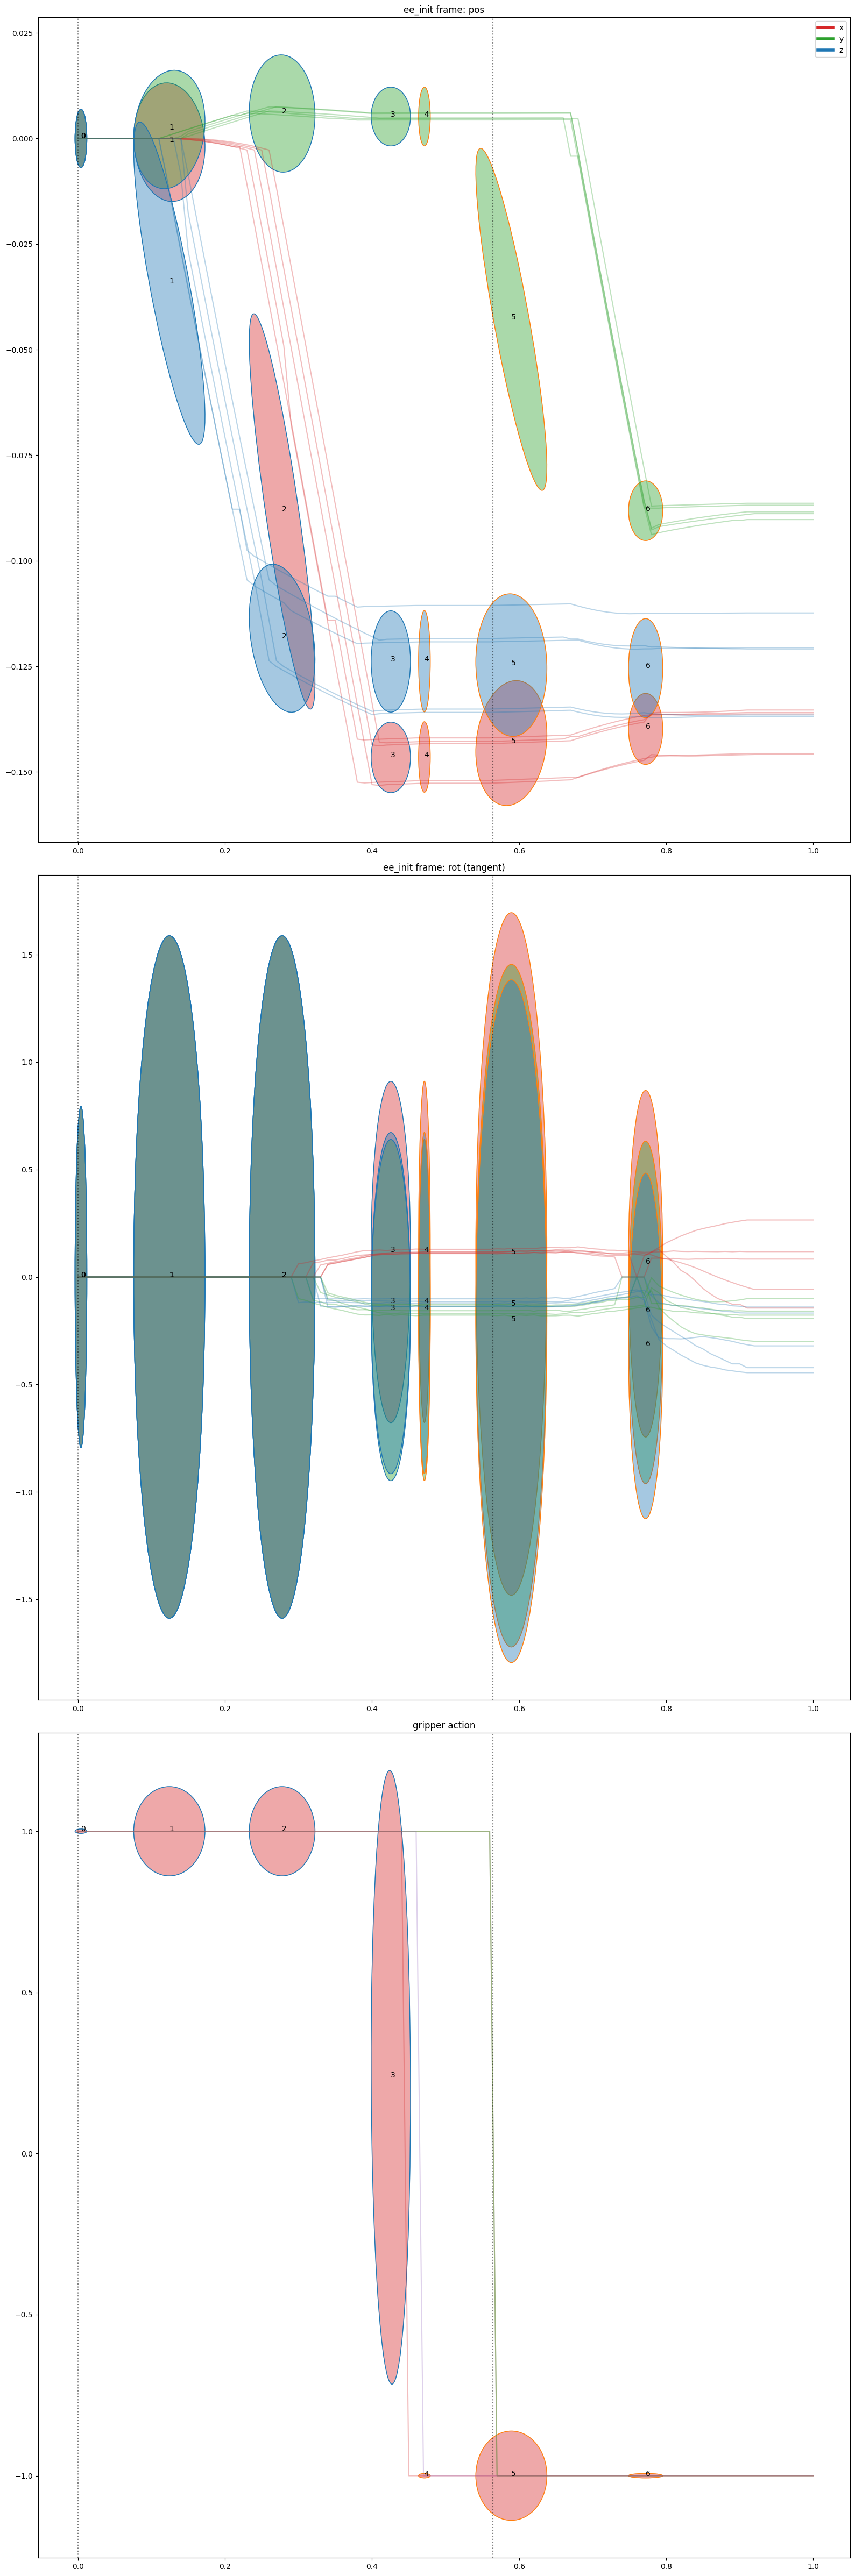

In [73]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

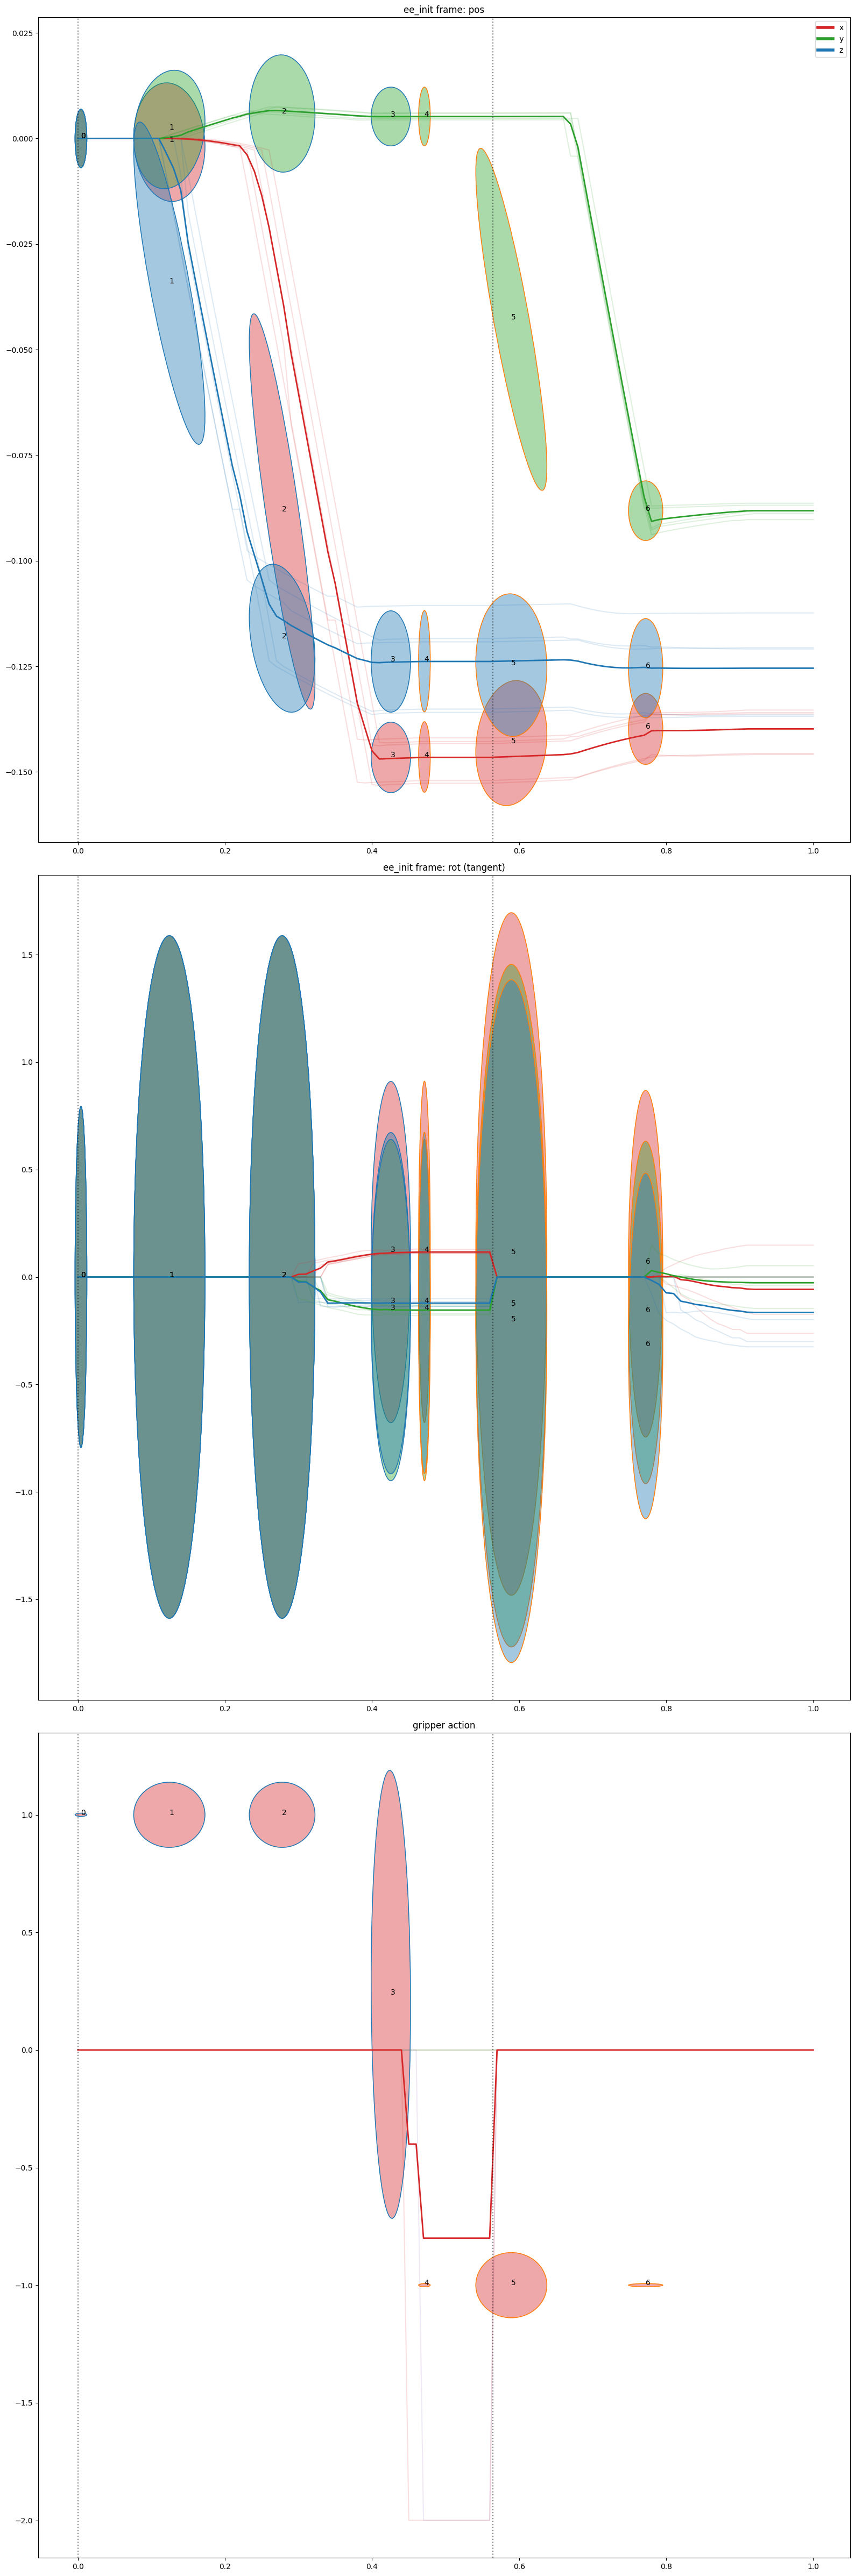

In [74]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=True, per_segment=False, gaussian_mean_only=False, plot_traj_means=True, time_based=True)

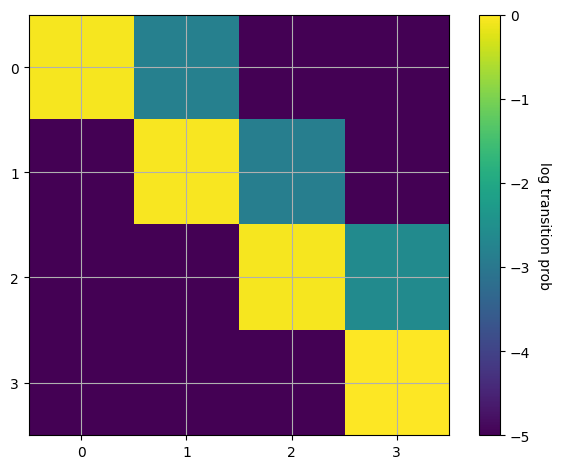

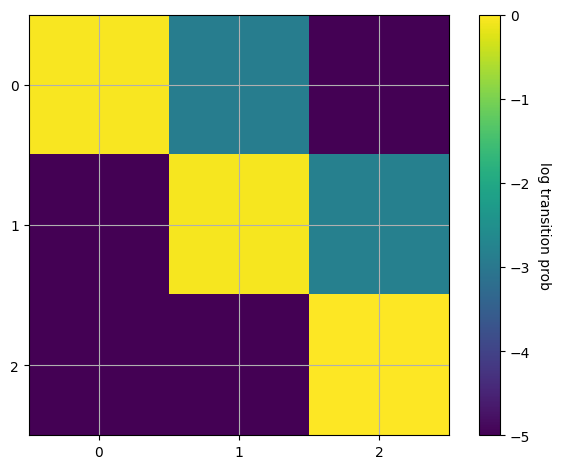

In [75]:
atpgmm.plot_hmm_transition_matrix()

In [76]:
atpgmm.to_disk(data_root / task / f'{serie}_gmm_policy-{tag}.pt')

In [77]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=tapas_gmm.policy.models.tpgmm.ReconstructionStrategy.GMR,
    use_ss=False)


2025-08-16 02:05:01.880 | INFO     |  Caculated segment transition probabilities: (array([[2.24e-09]]),)
2025-08-16 02:05:01.880 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 02:05:01.900 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

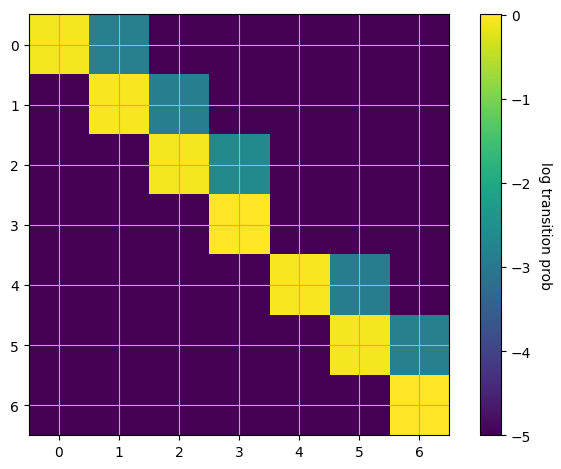

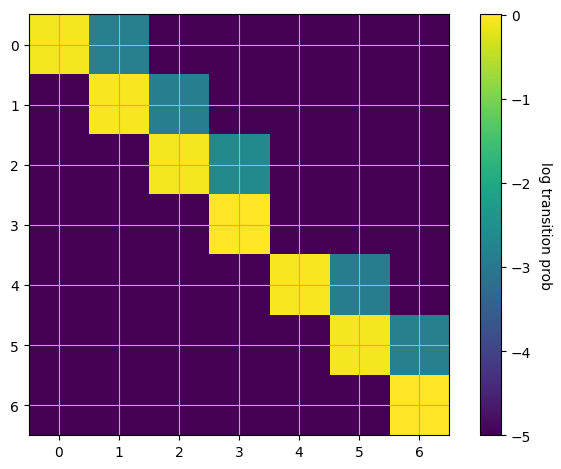

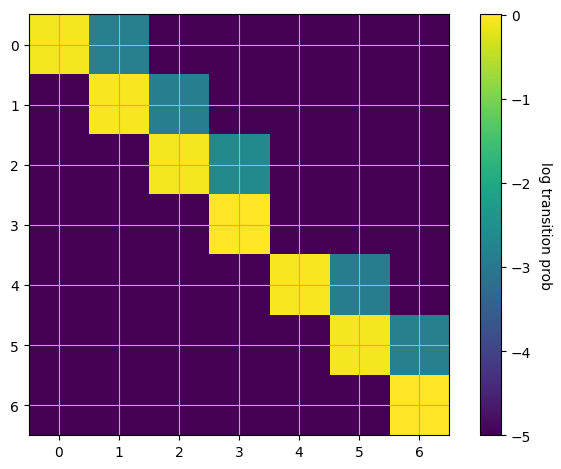

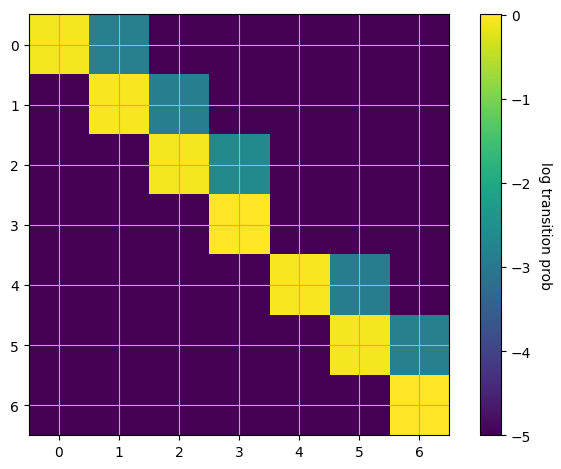

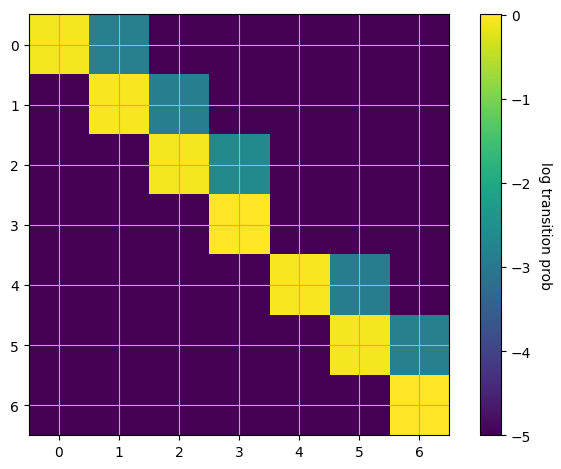

In [78]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2025-08-16 02:05:03.106 | INFO     |  Taking frame origins from demos.


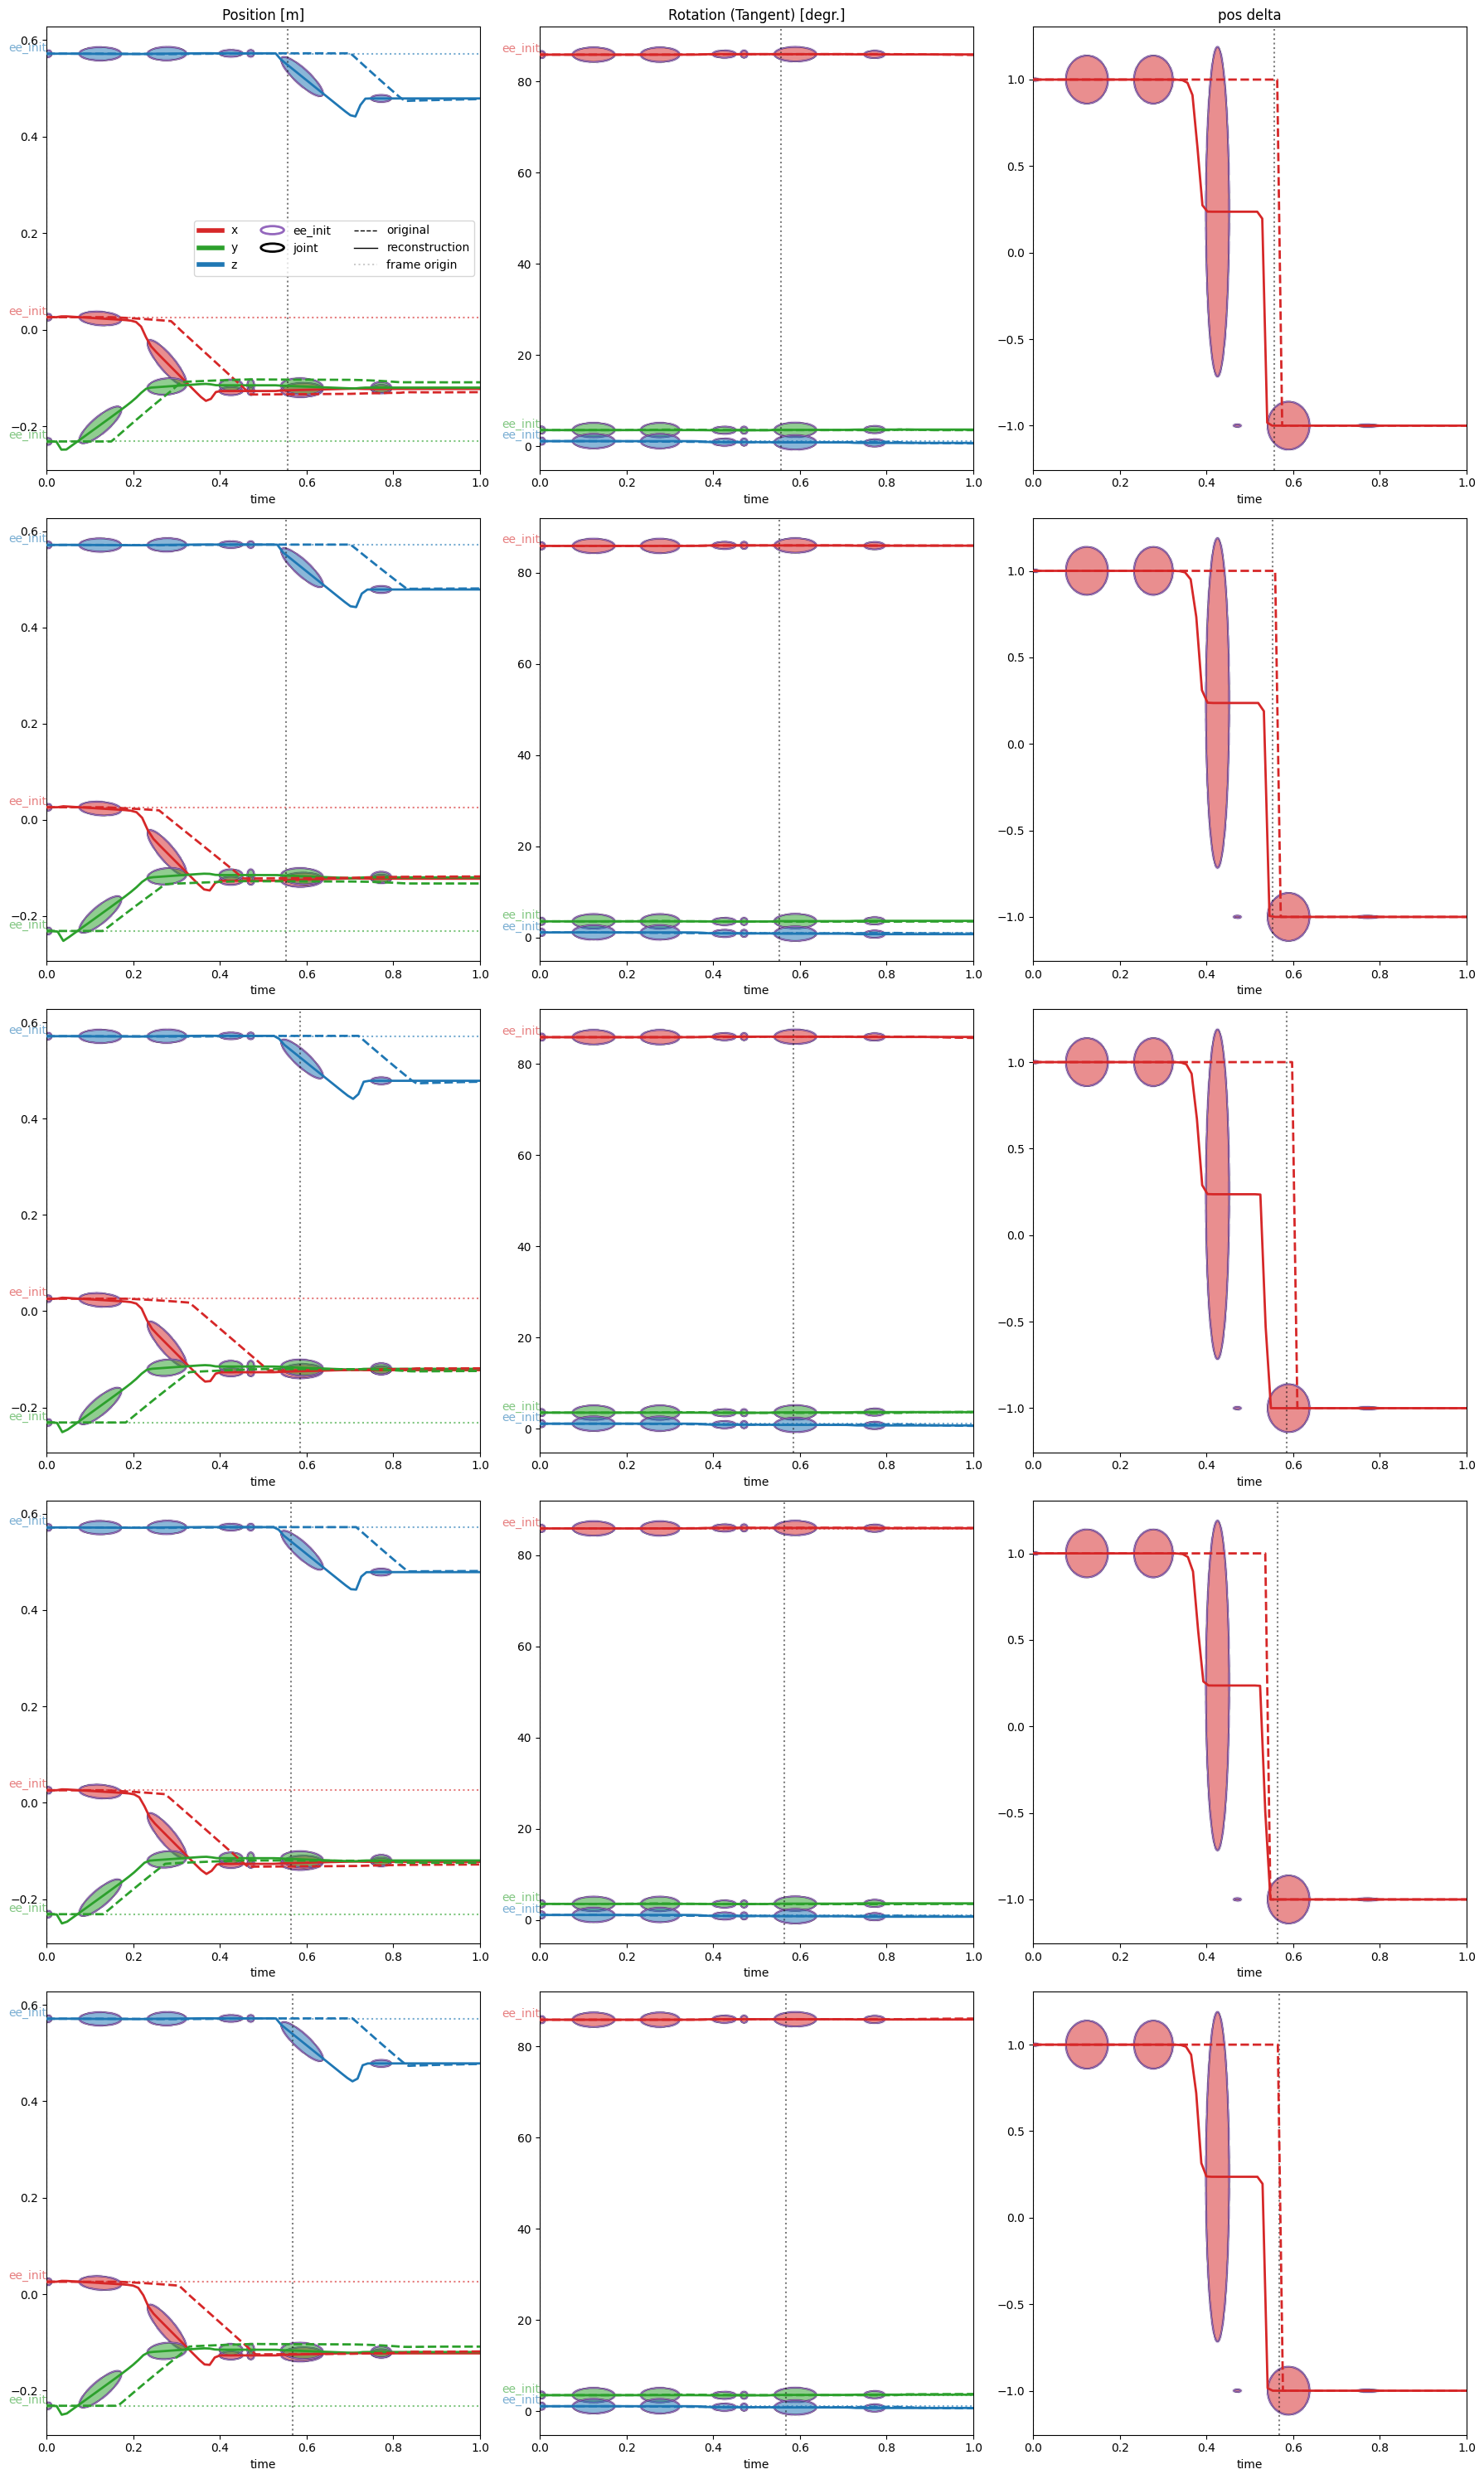

In [79]:
atpgmm.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [80]:
atpgmm.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=True,
    per_segment=False,
)

2025-08-16 02:05:04.961 | INFO     |  Taking frame origins from demos.


AttributeError: 'tuple' object has no attribute 'np_to_manifold_to_np'